In [1]:
# Import Libraries and Modules
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
CATEGORICAL_COLS = [
    "Protocol", "Label", "Dataset", "Dst Port"
]

INT8_COLS = [
    "FIN Flag Count", "SYN Flag Count", "RST Flag Count",
    "PSH Flag Count", "ACK Flag Count", "URG Flag Count",
    "CWR Flag Count", "ECE Flag Count",
    "Fwd PSH Flags", "Bwd PSH Flags",
    "Fwd URG Flags", "Bwd URG Flags"
]

INT32_COLS = [
    "Total Fwd Packet", "Total Bwd packets",
    "Fwd Header Length", "Bwd Header Length",
    "Subflow Fwd Packets", "Subflow Bwd Packets",
    "Subflow Fwd Bytes", "Subflow Bwd Bytes",
    "Fwd Act Data Pkts", "Fwd Seg Size Min",
    "FWD Init Win Bytes", "Bwd Init Win Bytes"
]

FLOAT32_COLS = [
    "Flow Duration", "Total Length of Fwd Packet",
    "Total Length of Bwd Packet", "Fwd Packet Length Max",
    "Fwd Packet Length Min", "Fwd Packet Length Mean",
    "Fwd Packet Length Std", "Bwd Packet Length Max",
    "Bwd Packet Length Min", "Bwd Packet Length Mean",
    "Bwd Packet Length Std", "Flow Bytes/s", "Flow Packets/s",
    "Flow IAT Mean", "Flow IAT Std", "Flow IAT Max", "Flow IAT Min",
    "Fwd IAT Total", "Fwd IAT Mean", "Fwd IAT Std", "Fwd IAT Max",
    "Fwd IAT Min", "Bwd IAT Total", "Bwd IAT Mean", "Bwd IAT Std",
    "Bwd IAT Max", "Bwd IAT Min", "Fwd Packets/s", "Bwd Packets/s",
    "Packet Length Min", "Packet Length Max", "Down/Up Ratio",
    "Packet Length Mean", "Packet Length Std",
    "Packet Length Variance", "Average Packet Size",
    "Fwd Segment Size Avg", "Bwd Segment Size Avg",
    "Fwd Bytes/Bulk Avg", "Fwd Packet/Bulk Avg", "Fwd Bulk Rate Avg",
    "Bwd Bytes/Bulk Avg", "Bwd Packet/Bulk Avg", "Bwd Bulk Rate Avg",
    "Active Mean", "Active Std", "Active Max", "Active Min",
    "Idle Mean", "Idle Std", "Idle Max", "Idle Min"
]

In [3]:
# DATA TYPE MAPPING
DTYPE_MAP = {col: "float32" for col in FLOAT32_COLS}
DTYPE_MAP.update({col: "int32" for col in INT32_COLS})
DTYPE_MAP.update({col: "int8" for col in INT8_COLS})

In [4]:
def DTYPEconversion(file):
    """ Optimises dataset usage by converting columns to predefined data types """

    # Temporary output file
    TMP_FILE = f"{file}.tmp"

    # Final output file
    OUTPUT_FILE = file

    # Tracks whether CSV header has already been written
    header_written = False

    # Read dataset in chunks
    for chunk in pd.read_csv(file, chunksize=500_000, low_memory=False):

        # Convert numerics
        for col in DTYPE_MAP:
            if col in chunk.columns:
                chunk[col] = pd.to_numeric(chunk[col], errors="coerce")

        # Replace infinities
        chunk.replace([np.inf, -np.inf], np.nan, inplace=True)

        # Apply optimised data types
        for col, dtype in DTYPE_MAP.items():
            if col in chunk.columns:
                chunk[col] = chunk[col].astype(dtype)

        # Convert categorical columns
        for col in CATEGORICAL_COLS:
            if col in chunk.columns:
                chunk[col] = chunk[col].astype("category")

        # Write to tmp file
        chunk.to_csv(
            TMP_FILE,
            mode="a",
            index=False,
            header=not header_written
        )
        header_written = True

    os.replace(TMP_FILE, OUTPUT_FILE)

In [ ]:
# Folder containing CSV capture files
INPUT_FOLDER = "/home/administrator/Desktop/captures/realtime/"

# Loop through all files in the input directory
for filename in os.listdir(INPUT_FOLDER):

    # Process only CSV files
    if filename.endswith(".csv"):
        
        INPUT_FILE = os.path.join(INPUT_FOLDER, filename)

        # Apply dtype optimisation and conversion   
        DTYPEconversion(INPUT_FILE)
        print(f"Finished processing {INPUT_FILE}")

Finished processing /home/administrator/Desktop/captures/realtime/ssh.csv
Finished processing /home/administrator/Desktop/captures/realtime/ping.csv
Finished processing /home/administrator/Desktop/captures/realtime/syn.csv
Finished processing /home/administrator/Desktop/captures/realtime/udp.csv
Finished processing /home/administrator/Desktop/captures/realtime/portscan.csv
Finished processing /home/administrator/Desktop/captures/realtime/web.csv


In [6]:
# Files that should be labelled 0 (Benign)
label_0_files = {
    "ssh.csv",
    "ping.csv",
    "web.csv"
}

# Files that should be labelled 1 (Malicious)
label_1_files = {
    "syn.csv",
    "udp.csv",
    "portscan.csv"
}

# Loop through all CSV files in the input folder
for filename in os.listdir(INPUT_FOLDER):

    # Process only CSV files
    if filename.endswith(".csv"):

        file_path = os.path.join(INPUT_FOLDER, filename)
        print(f"Processing: {filename}")

        df = pd.read_csv(file_path)

        # Assign label
        if filename in label_0_files:
            df["Binary Label"] = 0
            df["Attack Group"] = "Benign"

        elif filename in label_1_files:
            df["Binary Label"] = 1
            df["Attack Group"] = "Other"

        else:
            print(f"Skipping (not classified): {filename}")
            continue

        # Save file
        df.to_csv(file_path, index=False)

        print(f"Updated: {filename}\n")

print("All specified files updated.")

Processing: ssh.csv
Updated: ssh.csv

Processing: ping.csv
Updated: ping.csv

Processing: syn.csv
Updated: syn.csv

Processing: udp.csv
Updated: udp.csv

Processing: portscan.csv
Updated: portscan.csv

Processing: web.csv
Updated: web.csv

All specified files updated.


In [7]:
# Directory containing prediction outputs
PRED_DIR = "predictions/realtime-predictions/"

# Files representing benign network traffic
benign_files = {
    "Benign/predictions_ping_final.csv",
    "Benign/predictions_ssh_final.csv",
    "Benign/predictions_web_final.csv"
}

# Files representing attack network traffic
attack_files = {
    "Attacks/predictions_syn_final.csv",
    "Attacks/predictions_udp_final.csv",
    "Attacks/predictions_portscan_final.csv"
}

model_columns = ["LSTM", "DNN", "RF", "Majority", "Weighted"]


In [10]:
# Evaluate only benign files
for path in benign_files:

    file_path = os.path.join(PRED_DIR, path)

    df = pd.read_csv(file_path)
    print(f"\nProcessing: {path}")

    # Actual label
    y_true = (df["Actual"].str.lower() != "benign").astype(int)

    # Check predictions of every model
    for model in model_columns:

        # Predicted label
        y_pred = (df[model].str.lower() != "benign").astype(int)

        # Calculate total accuracy
        matches = (y_true == y_pred).sum()
        total = len(df)
        accuracy = (matches / total) * 100

        print(f"{model}: {matches}/{total} correct ({accuracy:.4f}%)")
    


Processing: Benign/predictions_web_final.csv
LSTM: 24/26 correct (92.3077%)
DNN: 26/26 correct (100.0000%)
RF: 26/26 correct (100.0000%)
Majority: 26/26 correct (100.0000%)
Weighted: 26/26 correct (100.0000%)

Processing: Benign/predictions_ssh_final.csv
LSTM: 8/20 correct (40.0000%)
DNN: 18/20 correct (90.0000%)
RF: 18/20 correct (90.0000%)
Majority: 20/20 correct (100.0000%)
Weighted: 12/20 correct (60.0000%)

Processing: Benign/predictions_ping_final.csv
LSTM: 5/5 correct (100.0000%)
DNN: 5/5 correct (100.0000%)
RF: 4/5 correct (80.0000%)
Majority: 5/5 correct (100.0000%)
Weighted: 5/5 correct (100.0000%)


In [11]:
# Evaluate only attack files
for path in attack_files:

    file_path = os.path.join(PRED_DIR, path)

    df = pd.read_csv(file_path)
    print(f"\nProcessing: {path}")

    # Actual label
    y_true = (df["Actual"].str.lower() != "benign").astype(int)

    # Check predictions of every model
    for model in model_columns:

        # Predicted label
        y_pred = (df[model].str.lower() != "benign").astype(int)

        # Calculate total accuracy
        matches = (y_true == y_pred).sum()
        total = len(df)
        accuracy = (matches / total) * 100

        print(f"{model}: {matches}/{total} correct ({accuracy:.4f}%)")
    


Processing: Attacks/predictions_portscan_final.csv
LSTM: 1051/2167 correct (48.5002%)
DNN: 3/2167 correct (0.1384%)
RF: 153/2167 correct (7.0605%)
Majority: 60/2167 correct (2.7688%)
Weighted: 117/2167 correct (5.3992%)

Processing: Attacks/predictions_syn_final.csv
LSTM: 99643/99644 correct (99.9990%)
DNN: 1/99644 correct (0.0010%)
RF: 0/99644 correct (0.0000%)
Majority: 0/99644 correct (0.0000%)
Weighted: 0/99644 correct (0.0000%)

Processing: Attacks/predictions_udp_final.csv
LSTM: 27034/27034 correct (100.0000%)
DNN: 27034/27034 correct (100.0000%)
RF: 27033/27034 correct (99.9963%)
Majority: 27033/27034 correct (99.9963%)
Weighted: 27033/27034 correct (99.9963%)


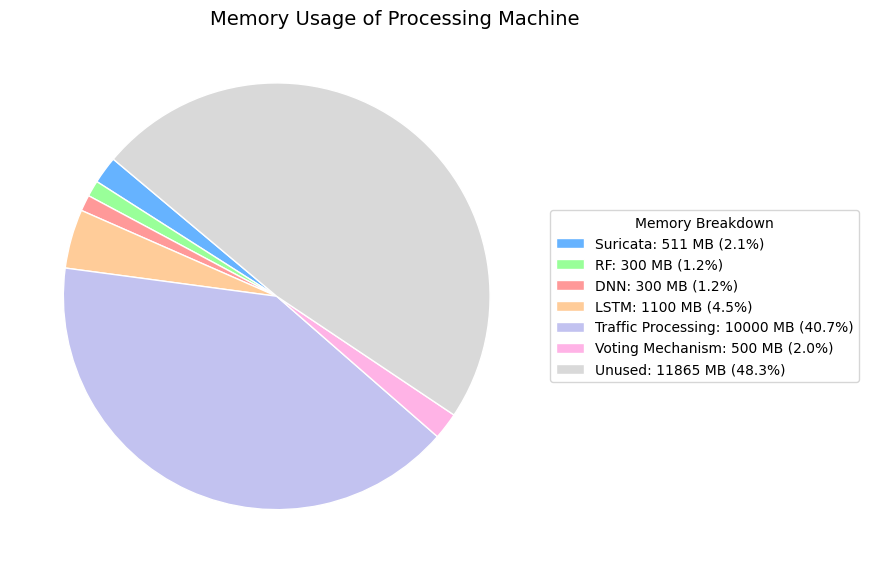

In [21]:
# Maximum memory
max_memory = 24 * 1024 

# Memory usage values in MB
labels = ['Suricata', 'RF', 'DNN', 'LSTM', 'Traffic Processing', 'Voting Mechanism']
values = [511, 300, 300, 1100, 10000, 500]

# Add unused memory
unused = max_memory - sum(values)
labels.append("Unused")
values.append(unused)

# Colors
colors = [
    '#66b3ff', '#99ff99', '#ff9999',
    '#ffcc99', '#c2c2f0', '#ffb3e6',
    '#d9d9d9'
]

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Draw pie chart
wedges, texts = ax.pie(
    values,
    labels=None,
    startangle=140,
    colors=colors,
    wedgeprops={'edgecolor': 'white'}
)

# Compute total for percentages
total = sum(values)

# Build legend with value + percentage
legend_labels = [
    f"{label}: {value} MB ({value / total * 100:.1f}%)"
    for label, value in zip(labels, values)
]

ax.legend(
    wedges,
    legend_labels,
    title="Memory Breakdown",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

# Display title
fig.suptitle("Memory Usage of Processing Machine", fontsize=14, y=0.95)

plt.tight_layout()
plt.show()